In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gdown

file_id = '1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh' # Extracted from the provided URL
output_filename = 'dataset.csv'

gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"File downloaded as '{output_filename}'")

Downloading...
From (original): https://drive.google.com/uc?id=1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh
From (redirected): https://drive.google.com/uc?id=1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh&confirm=t&uuid=385bb966-8dee-4d40-8427-cb848c9c3b3c
To: /content/dataset.csv
100%|██████████| 556M/556M [00:13<00:00, 40.4MB/s]

File downloaded as 'dataset.csv'


In [ ]:
import pandas as pd
df=pd.read_csv('dataset.csv')
df.head()

/tmp/ipykernel_3328/2353016527.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('dataset.csv')


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [ ]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [ ]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

,count
Subreddit,
depression,258490
Anxiety,86242
bipolar,41490
BPD,38210
schizophrenia,17505
autism,7142


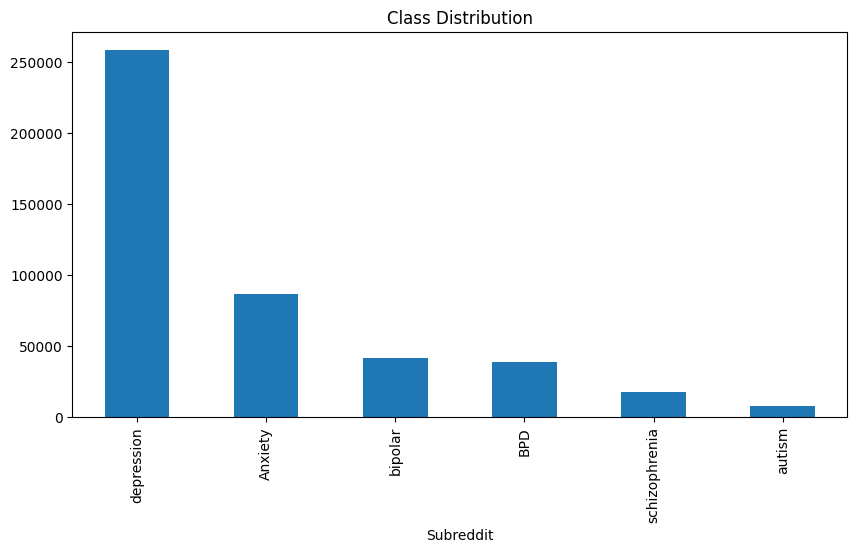

In [ ]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

In [ ]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

,text_length
count,449079.000000
mean,184.987488
std,224.415564
min,0.000000
25%,60.000000
50%,121.000000
75%,229.000000
max,6597.000000


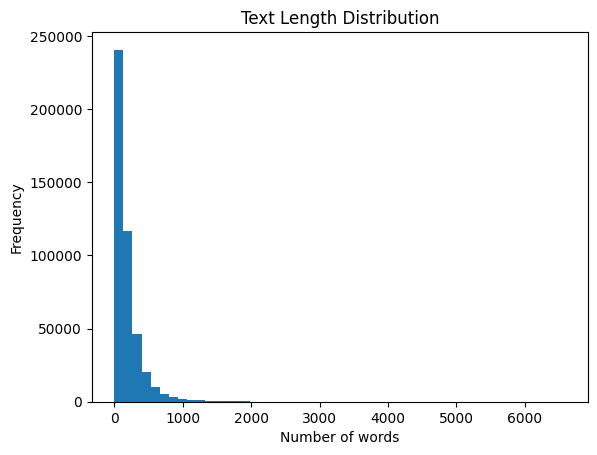

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


In [ ]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449000, 4)

In [ ]:
df["content"] = df["Title"] + " " + df["Text"]

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df["clean_text"]

,clean_text
0,exposure does not work i have struggled with s...
1,panic attack derealization cant go to doctors ...
2,how long can a panic attack last ive been with...
3,stepping stones first time poster long time lu...
4,coping with anxiety over climate change on the...
...,...
488733,religion and paranoid conversation ok ive got ...
488734,isnt this a little weird for being tardive dys...
488735,is this a symptom of schizophrenia or somethin...
488736,anyone seen the new black mirror episode bande...


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [ ]:
df["clean_text"].head()

,clean_text
0,exposure does work struggled social anxiety ch...
1,panic attack derealization doctors advice appr...
2,long panic attack ive withdrawing medicines la...
3,stepping stones time poster long time lurker i...
4,coping anxiety climate change verge considerin...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Subreddit"],
    random_state=42
)

print(train_df.shape, test_df.shape)

(359200, 6) (89800, 6)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

print(X_train.shape, X_test.shape)

(359200, 5000) (89800, 5000)


In [ ]:
from xgboost import XGBClassifier

def train_xgb(X_train, y_train):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    return model

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate_full(model, X_test, y_test):
    preds = model.predict(X_test)

    f1_pos = f1_score(y_test, preds, pos_label=1)  # disorder
    f1_neg = f1_score(y_test, preds, pos_label=0)  # non-disorder
    acc = accuracy_score(y_test, preds)

    return f1_neg, f1_pos, acc

In [ ]:
print(df["Subreddit"].unique())

['Anxiety' 'BPD' 'depression' 'autism' 'bipolar' 'schizophrenia']


In [ ]:
df["Subreddit"] = df["Subreddit"].str.lower()

train_df["Subreddit"] = train_df["Subreddit"].str.lower()
test_df["Subreddit"] = test_df["Subreddit"].str.lower()

In [ ]:
categories = ["depression", "anxiety", "bipolar", "bpd", "schizophrenia", "autism"]

In [ ]:
from imblearn.over_sampling import SMOTE

results_f1 = {}
results_acc = {}

for category in categories:
    print(f"\n===== {category} vs Rest =====")

    y_train = (train_df["Subreddit"] == category).astype(int)
    y_test = (test_df["Subreddit"] == category).astype(int)

    # 🔥 SMOTE FIX
    smote = SMOTE()
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    model = train_xgb(X_train_sm, y_train_sm)

    f1_neg, f1_pos, acc = evaluate_full(model, X_test, y_test)

    results_f1[category] = {
        "Non-" + category: f1_neg * 100,
        category: f1_pos * 100
    }

    results_acc[category] = acc * 100

    print(f"{category} Done")


===== depression vs Rest =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:48:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


depression Done

===== anxiety vs Rest =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:59:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


anxiety Done

===== bipolar vs Rest =====


...

bpd Done

===== schizophrenia vs Rest =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:21:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


schizophrenia Done

===== autism vs Rest =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


autism Done


In [ ]:
final_f1 = {}

for category in categories:
    final_f1[f"Non-{category[:3].capitalize()}"] = results_f1[category][f"Non-{category}"]
    final_f1[category[:3].capitalize()] = results_f1[category][category]

f1_table = pd.DataFrame([final_f1])
print('F1_score')
f1_table

F1_score


,Non-Dep,Dep,Non-Anx,Anx,Non-Bip,Bip,Non-Bpd,Bpd,Non-Sch,Sch,Non-Aut,Aut
0,81.458829,86.741534,94.543277,76.924421,96.928349,68.954855,95.902055,58.324523,95.625295,40.719436,98.844343,53.714286


In [ ]:
acc_table = pd.DataFrame.from_dict(results_acc, orient='index', columns=['Accuracy'])
acc_table

,Accuracy
depression,84.538976
anxiety,91.173719
bipolar,94.409800
bpd,92.537862
schizophrenia,91.851893
autism,97.744989
